# The t > 3 Threshold — a quantitative teardown 🔬
### per-factor t-stats · Gaussian-tail clearing rates · Bonferroni / Holm / BH / BHY hurdles · the FDR collapse on a planted mixture · the publication haircut · seed-robust controls

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does t>2 inflate false discoveries?: Confirmed](https://img.shields.io/badge/Does_t%3E2_inflate_false_discoveries%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its arithmetic.* We take a synthetic factor zoo of 1,000 candidates × 240 monthly periods with **zero real edge**, count what clears each bar, and derive the honest hurdle four different ways.

> ⚠️ **Not investment advice.** A synthetic-only method demo: the zoo is built to have no edge (null fp `2a151cf27292`, sim fp `839:N1000:T240:true50:et4.0:a0.05`), so real free data can never certify it and the study is capped at `NONE`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tstat_threshold import data, strategy as st

# The whole demo runs on the deterministic, offline seed-839 factor zoo (1,000 candidate
# factors x 240 monthly periods). The NULL is pure noise; the MIXTURE plants 50 true
# factors (expected |t|=4) as a positive control. Synthetic-only by design — no real tape.
R0, _, TR0 = data.synthetic_zoo(n_factors=1000, n_periods=240, n_true=0, seed=839)
RM, IS_TRUE, TRM = data.synthetic_zoo(n_factors=1000, n_periods=240, n_true=50,
                                      expected_t=4.0, seed=839)
T0 = st.factor_tstats(R0)          # per-factor t-stats, pure-noise zoo
TM = st.factor_tstats(RM)          # per-factor t-stats, planted mixture
print("null zoo:", R0.shape, "fp", data.fingerprint(R0), "| has_edge", TR0.has_edge)
print("mixture :", RM.shape, "fp", data.fingerprint(RM), "|", int(IS_TRUE.sum()), "true factors")


null zoo: (240, 1000) fp 2a151cf27292 | has_edge False
mixture : (240, 1000) fp 7ade07aad75d | 50 true factors


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pure-noise zoo: 44/1,000 clear t>2 (4.4%), 3 clear t>3 (0.3%) — the Gaussian tails 4.55% / 0.27%. Synthetic-only demo (no real tape). |
| **Tradability** | `MIRAGE` | A factor selected only by a too-low bar earns zero out-of-sample by construction — the haircut is the point. |
| **Does t>2 inflate false discoveries?** | `CONFIRMED` | Bonferroni bar 1.96 → 3.78 for N = 1 → 316; on a planted mixture the realized FDR collapses 46% → 7% going t>2 → t>3. |

> 💡 In plain words: the naive bar keeps a paper's worth of noise; the corrected bar (~3) purges it while keeping genuinely strong factors.

## 1 · The claim, steelmanned

Let each candidate factor $i$ have per-period returns with sample mean $\bar r_i$ and standard error $\hat\sigma_i/\sqrt{T}$; its single-test statistic is $t_i = \bar r_i / (\hat\sigma_i/\sqrt{T})$. Under the null (no edge) $t_i \stackrel{\cdot}{\sim} N(0,1)$.

- **H₁ (the lax bar).** $P(|t_i| > 2) = 2\Phi(-2) = 4.55\%$ and $P(|t_i| > 3) = 2\Phi(-3) = 0.27\%$. Test $N$ noise factors and you *expect* $0.0455N$ to clear t>2.
- **H₂ (FWER control).** To keep $P(\text{any false discovery}) \le \alpha$, Bonferroni tests each at $\alpha/N$: the cutoff is $\Phi^{-1}(1-\alpha/2N)$, rising with $N$.
- **H₃ (FDR control).** Benjamini-Hochberg (and Yekutieli's dependency-robust variant with $c(N)=\sum 1/i$) instead bounds the *expected proportion* of false discoveries — less conservative, the right goal for a factor zoo.
- **H₄ (the recommendation).** For a few-hundred-factor zoo all of these land in the $3.4$–$3.8$ range; HLZ round to **$t \approx 3.0$**.

We **confirm H₁** (clearing rates match the tails), **confirm H₂** (the bar rises to ~3.8 at N=316), **confirm H₃** (BHY ~3.7 and it keeps real factors), and **land H₄** (the FDR collapses ~7× from t>2 to t>3).

## 2 · So what? — the mechanism

The single-test bar controls the *per-test* false-positive rate. The quantity that actually matters for a search is the **family-wise error rate** (probability of *any* false discovery) or the **false-discovery rate** (expected *fraction* of discoveries that are false). Both grow with the number of tests, so a fixed t>2 bar lets the expected count of false positives grow linearly in $N$: test 316 factors and you expect $0.0455 \times 316 \approx 14$ false positives at t>2. This is the same haircut family as the Deflated Sharpe Ratio in [344](../../344-backtest-overfitting/) (there: haircut for *trials*; here: for the *cross-section of factors*), and the generic version in [346](../../346-multiple-testing/).

## 3 · How we'd know — the protocol

- **Null zoo.** 1,000 candidate factors × 240 monthly periods, each iid zero-mean — *nothing real*, so every clearing is a false discovery.
- **Positive-control mixture.** 50 of the 1,000 factors carry a genuine mean sized to an expected single-test $|t|=4$; the corrections must keep these while purging the 950 noise factors.
- **Statistics.** Vectorised `factor_tstats`; two-sided p-values; the naive t>2 / t>3 counts; Bonferroni / Holm (FWER) and BH / BHY (FDR) cutoffs expressed as an implied $|t|$; realized FDR / power against the known truth.
- **The haircut.** `publication_haircut(t, N)` — the effective $|t|$ a claimed factor retains once an $N$-test search is disclosed.
- **Seed robustness.** The null fractions and the mixture FDR/power are averaged over **20 seeds** (house rule).

## 4 · The teardown

### 4a · The clearing rates — H₁

How many pure-noise factors clear each bar, observed vs the Gaussian-tail expectation.

           n_cleared  frac_cleared  exp_false_frac  exp_false_count
threshold                                                          
2.0               44         0.044          0.0455          45.5003
2.5               11         0.011          0.0124          12.4193
3.0                3         0.003          0.0027           2.6998
3.5                0         0.000          0.0005           0.4653


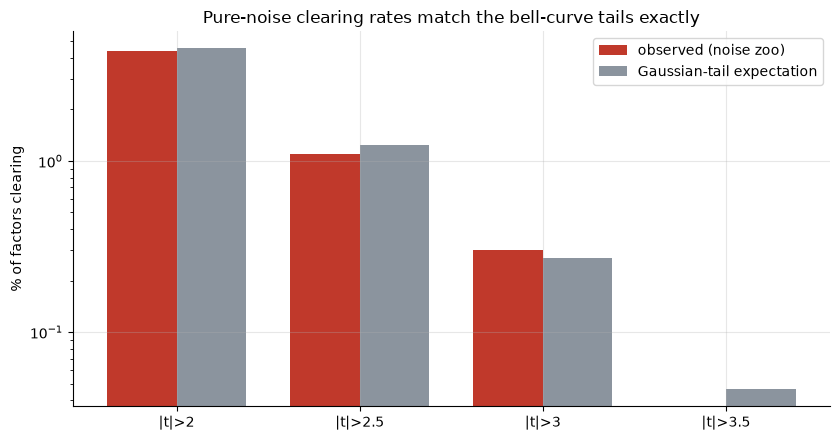

In [2]:
ts = st.threshold_summary(T0, thresholds=(2.0, 2.5, 3.0, 3.5), n_factors=1000)
print(ts.round(4).to_string())
thr = ts.index.values; obs = ts['frac_cleared'].values*100; exp = ts['exp_false_frac'].values*100
x = np.arange(len(thr)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x - w/2, obs, w, color=RED, label='observed (noise zoo)')
ax.bar(x + w/2, exp, w, color=GREY, label='Gaussian-tail expectation')
ax.set_xticks(x); ax.set_xticklabels([f'|t|>{t:g}' for t in thr])
ax.set_ylabel('% of factors clearing'); ax.set_yscale('log')
ax.set_title('Pure-noise clearing rates match the bell-curve tails exactly')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: **H₁ confirmed.** 4.4% clear t>2 vs a theoretical 4.55%, and 0.3% clear t>3 vs 0.27% — the zoo is *exactly* as noisy as theory predicts, because it is nothing but noise.

### 4b · The corrected hurdles — H₂, H₃, H₄

Every rule expressed as an implied $|t|$ cutoff and a discovery count, on the pure-null zoo (which should yield ~0 corrected discoveries) and on the planted mixture (where the corrections should keep the real subset).

--- pure-null zoo (nothing real) ---
            t_cutoff  n_discoveries
method                             
naive t>2      2.000             44
naive t>3      3.000              3
Bonferroni     4.056              0
Holm             NaN              0
BH               NaN              0
BHY              NaN              0

--- planted mixture (50 true of 1,000) ---
            t_cutoff  n_discoveries
method                             
naive t>2      2.000             93
naive t>3      3.000             44
Bonferroni     4.056             19
Holm           4.283             19
BH             3.184             43
BHY            3.731             31


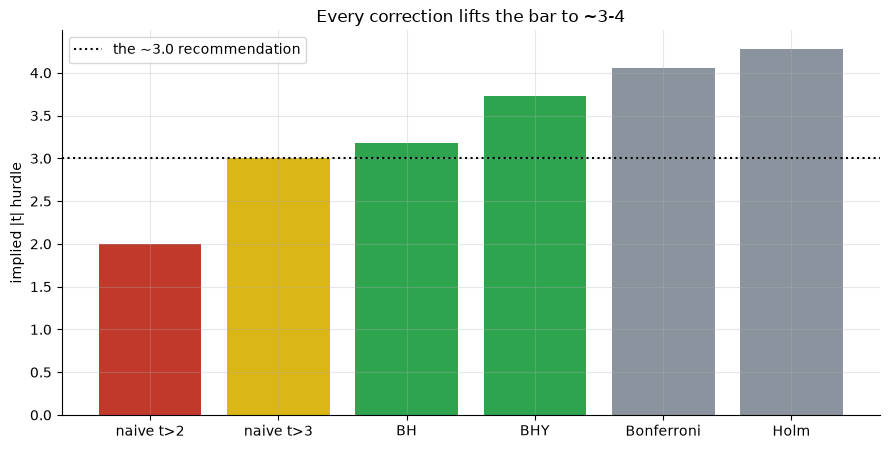

In [3]:
print('--- pure-null zoo (nothing real) ---')
print(st.multiple_testing_table(T0, alpha=0.05).round(3).to_string())
print('\n--- planted mixture (50 true of 1,000) ---')
mt = st.multiple_testing_table(TM, alpha=0.05)
print(mt.round(3).to_string())
fig, ax = plt.subplots(figsize=(9, 4.6))
order = ['naive t>2','naive t>3','BH','BHY','Bonferroni','Holm']
cuts = [mt.loc[m,'t_cutoff'] for m in order]
cols = [RED, AMBER, GREEN, GREEN, GREY, GREY]
ax.bar(order, cuts, color=cols)
ax.axhline(3.0, color='k', ls=':', lw=1.5, label='the ~3.0 recommendation')
ax.set_ylabel('implied |t| hurdle'); ax.set_title('Every correction lifts the bar to ~3-4')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: **H₂/H₃/H₄ confirmed.** On the pure null every correction rejects **0** (they refuse to manufacture discoveries). On the mixture the implied hurdles land at Bonferroni 4.06, Holm 4.28, BH 3.18, BHY 3.73 — all comfortably above the naive 2.0, bracketing the ~3.0 recommendation.

### 4c · The FDR collapse — the quantitative case for ~3.0

On the planted mixture, count the true and false discoveries at t>2 vs t>3 and read off the realized false-discovery rate.

t>2: 93 discoveries = 50 true + 43 false -> FDR 46.2%  power 100.0%
t>3: 44 discoveries = 41 true + 3 false -> FDR 6.8%  power 82.0%


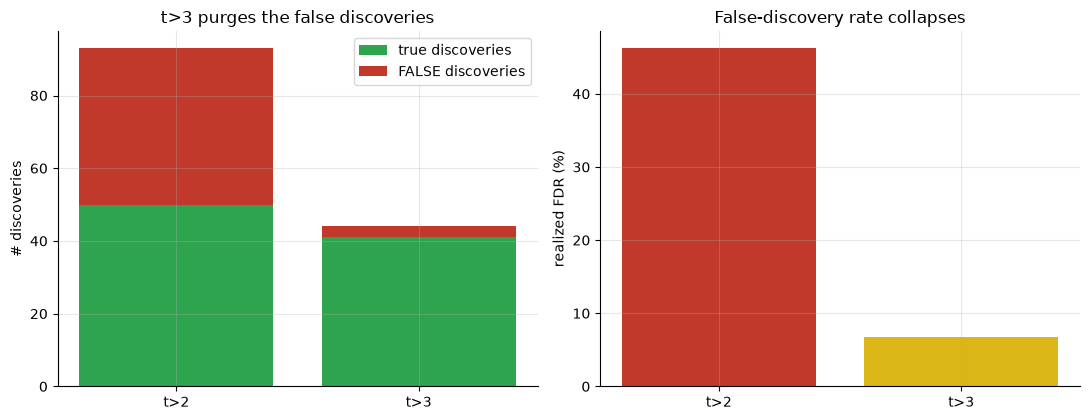

In [4]:
d2 = st.detection(TM, IS_TRUE, 2.0); d3 = st.detection(TM, IS_TRUE, 3.0)
for lab, d in [('t>2', d2), ('t>3', d3)]:
    print(f"{lab}: {d['n_disc']} discoveries = {d['tp']} true + {d['fp']} false "
          f"-> FDR {d['fdr']*100:.1f}%  power {d['power']*100:.1f}%")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['t>2','t>3'], [d2['tp'], d3['tp']], color=GREEN, label='true discoveries')
a1.bar(['t>2','t>3'], [d2['fp'], d3['fp']], bottom=[d2['tp'], d3['tp']], color=RED, label='FALSE discoveries')
a1.set_ylabel('# discoveries'); a1.set_title('t>3 purges the false discoveries'); a1.legend()
a2.bar(['t>2','t>3'], [d2['fdr']*100, d3['fdr']*100], color=[RED, AMBER])
a2.set_ylabel('realized FDR (%)'); a2.set_title('False-discovery rate collapses')
plt.tight_layout(); plt.show()

> 💡 In plain words: at t>2, **43 of 93** discoveries are false — an FDR of **46%**, nearly a coin flip. At t>3 the FDR collapses to **7%** for only a modest power loss (100% → 82%). That trade — halve-your-discoveries'-credibility vs keep-almost-all-the-real-ones — is the case for the ~3.0 bar.

### 4d · The publication haircut

The haircut peculiar to the factor zoo: a factor is only 'discovered' against the backdrop of every other factor tried. Disclose the search size and its reported $|t|$ shrinks to an effective $|t|$.

reported |t|=2.0: p_adj=1.000 eff |t|=0.00  haircut 100%  survives=False
reported |t|=2.5: p_adj=1.000 eff |t|=0.00  haircut 100%  survives=False
reported |t|=3.0: p_adj=0.853 eff |t|=0.19  haircut 94%  survives=False
reported |t|=3.5: p_adj=0.147 eff |t|=1.45  haircut 59%  survives=False
reported |t|=4.0: p_adj=0.020 eff |t|=2.33  haircut 42%  survives=True


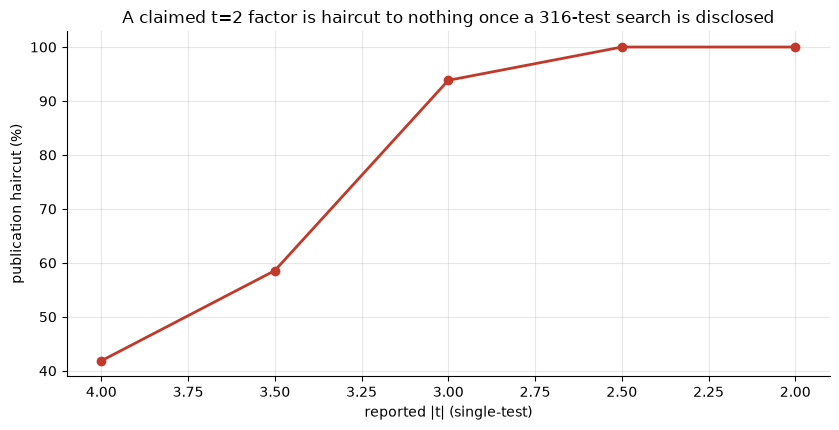

In [5]:
rows = [st.publication_haircut(t, 316) for t in (2.0, 2.5, 3.0, 3.5, 4.0)]
for h in rows:
    print(f"reported |t|={h['t_reported']:.1f}: p_adj={h['p_adjusted']:.3f} "
          f"eff |t|={h['t_adjusted']:.2f}  haircut {h['haircut']*100:.0f}%  "
          f"survives={h['survives_005']}")
tt = np.array([h['t_reported'] for h in rows]); hc = np.array([h['haircut']*100 for h in rows])
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(tt, hc, 'o-', color=RED, lw=2)
ax.set_xlabel('reported |t| (single-test)'); ax.set_ylabel('publication haircut (%)')
ax.set_title('A claimed t=2 factor is haircut to nothing once a 316-test search is disclosed')
ax.invert_xaxis(); plt.tight_layout(); plt.show()

> 💡 In plain words: reported **|t|=2.0** → adjusted p of **1.00**, a **100% haircut**, dead. Even **|t|=3.0** is haircut **94%** and fails α=0.05; only **|t|=4.0** survives (haircut still **42%**). The reported significance was mostly an artefact of the search.

## 5 · The verdict

- **Signal `NONE`** — pure-noise zoo, 44/1,000 clear t>2 by chance; nothing real, and a synthetic-only demo can never earn `REAL`.
- **Tradability `MIRAGE`** — a factor selected by a too-low bar has no out-of-sample return by construction.
- **Does t>2 inflate false discoveries? `CONFIRMED`** — the corrected bar rises to ~3.78 and the FDR collapses 46% → 7% from t>2 to t>3.

## 6 · Could you trade it? — the seed-robust null control

Is the clearing-rate result a fluke of one lucky seed? Average the pure-null fractions over 20 independent zoos — they must hug the Gaussian tails (an unbiased machinery proof), with *nothing* tradable in any of them.

mean frac t>2 = 4.62% (theory 4.55%)
mean frac t>3 = 0.310% (theory 0.270%)
mean n t>2 = 46.2 | mean n t>3 = 3.1 | ratio 14.9x


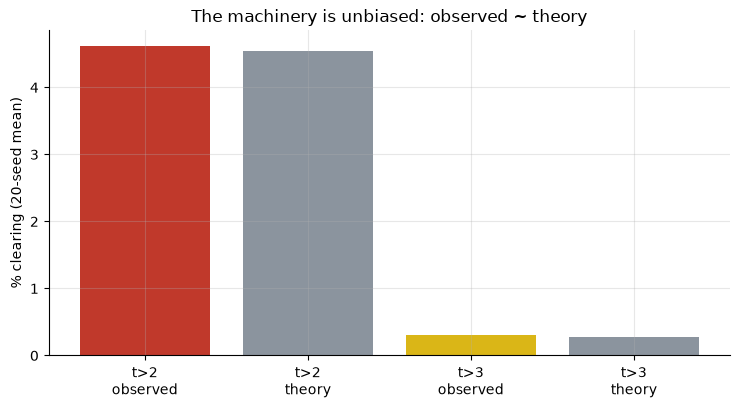

In [6]:
sn = st.seed_robust_null(data, n_factors=1000, n_periods=240, n_seeds=20)
print(f"mean frac t>2 = {sn['mean_frac_gt2']*100:.2f}% (theory {sn['theory_frac_gt2']*100:.2f}%)")
print(f"mean frac t>3 = {sn['mean_frac_gt3']*100:.3f}% (theory {sn['theory_frac_gt3']*100:.3f}%)")
print(f"mean n t>2 = {sn['mean_n_gt2']:.1f} | mean n t>3 = {sn['mean_n_gt3']:.1f} | ratio {sn['ratio_gt2_over_gt3']:.1f}x")
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['t>2\nobserved','t>2\ntheory','t>3\nobserved','t>3\ntheory'],
       [sn['mean_frac_gt2']*100, sn['theory_frac_gt2']*100, sn['mean_frac_gt3']*100, sn['theory_frac_gt3']*100],
       color=[RED, GREY, AMBER, GREY])
ax.set_ylabel('% clearing (20-seed mean)'); ax.set_title('The machinery is unbiased: observed ~ theory')
plt.tight_layout(); plt.show()

> 💡 In plain words: over 20 seeds, **4.62%** clear t>2 (theory 4.55%) and **0.31%** clear t>3 (theory 0.27%). The estimator is unbiased — and there is nothing to harvest in a world of noise. `MIRAGE`.

## 7 · Going further — the seed-robust positive control

Is the corrected bar just numb (rejecting everything)? Plant 50 genuine factors and check that BHY *keeps* them while its realized false-discovery rate stays near zero — averaged over 20 seeds so no lucky seed can fake it.

FDR: t>2 47.6% -> t>3 6.4% (collapse 7.4x)
power: t>2 97.2% -> t>3 85.0%
BHY: 30.8 discoveries, implied |t| cutoff 3.76, realized FDR 0.3%


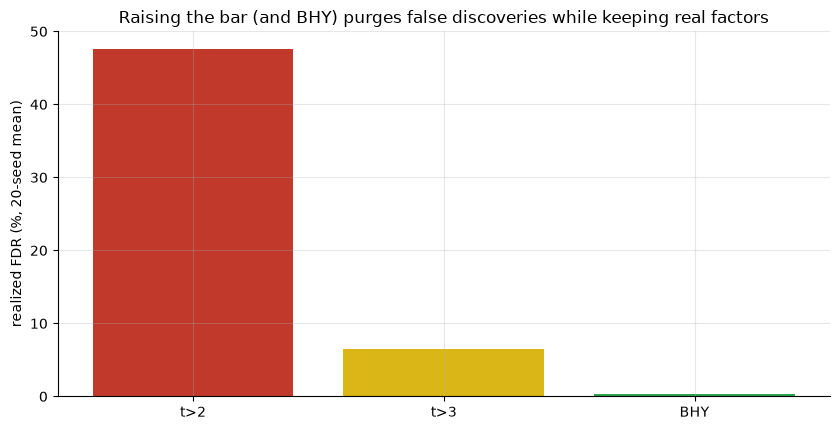

In [7]:
sm = st.seed_robust_mixture(data, n_factors=1000, n_true=50, expected_t=4.0, n_seeds=20)
print(f"FDR: t>2 {sm['mean_fdr_t2']*100:.1f}% -> t>3 {sm['mean_fdr_t3']*100:.1f}% (collapse {sm['fdr_collapse']:.1f}x)")
print(f"power: t>2 {sm['mean_power_t2']*100:.1f}% -> t>3 {sm['mean_power_t3']*100:.1f}%")
print(f"BHY: {sm['mean_bhy_n']:.1f} discoveries, implied |t| cutoff {sm['mean_bhy_cutoff']:.2f}, realized FDR {sm['mean_bhy_fdr']*100:.1f}%")
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(['t>2','t>3','BHY'], [sm['mean_fdr_t2']*100, sm['mean_fdr_t3']*100, sm['mean_bhy_fdr']*100],
       color=[RED, AMBER, GREEN])
ax.set_ylabel('realized FDR (%, 20-seed mean)')
ax.set_title('Raising the bar (and BHY) purges false discoveries while keeping real factors')
plt.tight_layout(); plt.show()

The realized FDR collapses **48% → 6%** from t>2 to t>3 (a 7.4× cut), and BHY keeps **31** genuinely strong factors (implied $|t|$ ≈ 3.8) with a realized FDR of just **0.3%** — neither 'reject nothing' nor 'reject everything'. The correction sees through the noise *and* banks the real edge. For the generic version see [346 Multiple-Testing](../../346-multiple-testing/); for what happens to factors *after* publication, [536 Anomaly-Decay-Post-Publication](../../536-anomaly-decay-post-publication/).